### Setup Environment

In [2]:
import os
import librosa
import numpy as np
from scipy.io.wavfile import write
import matplotlib.pyplot as plt
import librosa.display
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Concatenate, Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


### Preprocessing

In [4]:
def preprocess_audio(file_path, target_duration=1.5, sample_rate=8000):
    audio, sr = librosa.load(file_path, sr=sample_rate)
    audio = librosa.util.normalize(audio)
    audio_trimmed, _ = librosa.effects.trim(audio, top_db=30)
    
    if len(audio_trimmed) < int(target_duration * sr):
        audio_trimmed = librosa.util.fix_length(audio_trimmed, size=int(target_duration * sr))
    else:
        audio_trimmed = audio_trimmed[:int(target_duration * sr)]
    
    return audio_trimmed, sr

In [5]:
DATA_DIR = './data'
OUTPUT_DIR = './processed_audio'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Apply preprocessing and save processed audio
def save_preprocessed_audio():
    for label in ['HC_AH', 'PD_AH']:
        label_dir = os.path.join(DATA_DIR, label)
        output_label_dir = os.path.join(OUTPUT_DIR, label)
        os.makedirs(output_label_dir, exist_ok=True)
        for file_name in os.listdir(label_dir):
            audio, sr = preprocess_audio(os.path.join(label_dir, file_name))
            write(os.path.join(output_label_dir, file_name), sr, (audio * 32767).astype(np.int16))

save_preprocessed_audio()
print(f"Processed audio saved to: {OUTPUT_DIR}")

Processed audio saved to: ./processed_audio


### Spectrogram Generation

In [7]:
def generate_spectrogram(file_path, output_path, img_size=(600, 600)):
    y, sr = librosa.load(file_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=512)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    plt.figure(figsize=(img_size[0] / 100, img_size[1] / 100), dpi=100)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
    plt.axis('off')
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()

In [8]:
# Generate spectrograms for all processed audio files
SPECTROGRAM_DIR = './spectrograms'
os.makedirs(SPECTROGRAM_DIR, exist_ok=True)

def save_spectrograms():
    for label in ['HC_AH', 'PD_AH']:
        label_dir = os.path.join(OUTPUT_DIR, label)
        spectrogram_label_dir = os.path.join(SPECTROGRAM_DIR, label)
        os.makedirs(spectrogram_label_dir, exist_ok=True)
        for file_name in os.listdir(label_dir):
            generate_spectrogram(
                os.path.join(label_dir, file_name),
                os.path.join(spectrogram_label_dir, file_name.replace('.wav', '.png'))
            )
            
save_spectrograms()
print(f"Spectrograms saved in: {SPECTROGRAM_DIR}")

Spectrograms saved in: ./spectrograms


### Display Example Spectrogram

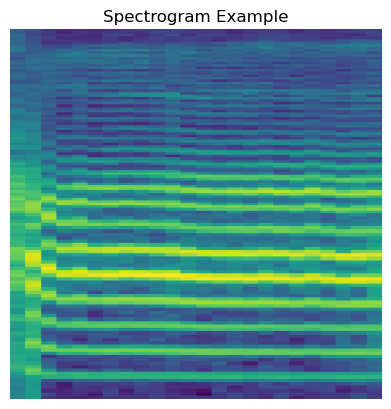

In [10]:
example_file = os.path.join(SPECTROGRAM_DIR, 'HC_AH', os.listdir(os.path.join(SPECTROGRAM_DIR, 'HC_AH'))[0])
img = plt.imread(example_file)
plt.imshow(img)
plt.axis('off')
plt.title("Spectrogram Example")
plt.show()


### Feature-Level Combination CNN

In [12]:
def build_feature_level_cnn(input_shape=(600, 600, 3)):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers:
        layer.trainable = False

    x = Flatten()(base_model.output)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(1, activation='sigmoid')(x)

    model = Model(base_model.input, x)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

feature_level_cnn = build_feature_level_cnn()
feature_level_cnn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 600, 600,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 299, 299,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 299, 299,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 299, 299,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 297, 297,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 297, 297,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 297, 297,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 297, 297,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 297, 297,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 297, 297,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 148, 148,  │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 148, 148,  │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 148, 148,  │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 148, 148,  │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 146, 146,  │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 146, 146,  │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 146, 146,  │          0 │ batch_normalizat

 Total params: 99,930,145 (381.20 MB)

 Trainable params: 76,943,617 (293.52 MB)

 Non-trainable params: 22,986,528 (87.69 MB)

### Model-Level Combination CNN

In [14]:
def build_model_level_cnn(input_shapes):
    inputs = [Input(shape=shape) for shape in input_shapes]
    conv_blocks = []

    for inp in inputs:
        x = Conv2D(32, kernel_size=(3, 3), activation='relu')(inp)
        x = MaxPooling2D(pool_size=(2, 2))(x)
        x = GlobalAveragePooling2D()(x)  # Replace Flatten with GlobalAveragePooling2D
        conv_blocks.append(x)

    merged = Concatenate()(conv_blocks)
    x = Dense(64, activation='relu')(merged)  # Reduce Dense units to 64
    x = Dropout(0.5)(x)
    x = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, x)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Example input shapes with reduced dimensions
model_level_cnn = build_model_level_cnn([(224, 224, 3), (224, 224, 3)])
model_level_cnn.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 222, 222,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 222, 222,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 111, 111,  │          0 │ conv2d_94[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 111, 111,  │          0 │ conv2d_95[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling2d_4[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling2d_5[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

### Data Preparation

In [16]:
IMG_SIZE = (600, 600)
BATCH_SIZE = 8

train_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.3)
train_generator = train_datagen.flow_from_directory(
    SPECTROGRAM_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)
val_generator = train_datagen.flow_from_directory(
    SPECTROGRAM_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 404 images belonging to 2 classes.
Found 172 images belonging to 2 classes.


### Model Training and Evaluation

In [ ]:
EPOCHS = 20

history_feature = feature_level_cnn.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)
history_model = model_level_cnn.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)

# Save models
feature_level_cnn.save('feature_level_cnn_model.keras')
model_level_cnn.save('model_level_cnn_model.keras')

# Plot results
def plot_training(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title} Accuracy')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

plot_training(history_feature, "Feature-Level CNN")
plot_training(history_model, "Model-Level CNN")

# Evaluate
evaluation_feature = feature_level_cnn.evaluate(val_generator)
evaluation_model = model_level_cnn.evaluate(val_generator)

print(f"Feature-Level CNN Accuracy: {evaluation_feature[1]:.2f}")
print(f"Model-Level CNN Accuracy: {evaluation_model[1]:.2f}")


C:\Users\aksha\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - accuracy: 0.7569 - loss: 27.2965 - val_accuracy: 0.6919 - val_loss: 50.2201
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 180s 4s/step - accuracy: 0.8676 - loss: 37.3332 - val_accuracy: 0.6570 - val_loss: 87.5275
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.9212 - loss: 13.5676 - val_accuracy: 0.6628 - val_loss: 87.3975
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - accuracy: 0.9272 - loss: 19.3527 - val_accuracy: 0.7035 - val_loss: 76.0830
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.9617 - loss: 9.8129 - val_accuracy: 0.7326 - val_loss: 76.2956
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.9634 - loss: 8.0410 - val_accuracy: 0.6977 - val_loss: 106.3540
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.9631 - loss: 7.4392 - val_accuracy: 0.6628 - val_loss: 119.3538
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.9541 - loss: 11.7449 - val_accura